In [5]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import json

# import all json files
with open("evaluation_metrics_bert.json", "r") as f:
    bert_metrics = json.load(f)

with open("evaluation_metrics_dictionary.json", "r") as f:
    dictionary_metrics = json.load(f)

# combine all models
all_metrics = {**bert_metrics, **dictionary_metrics}

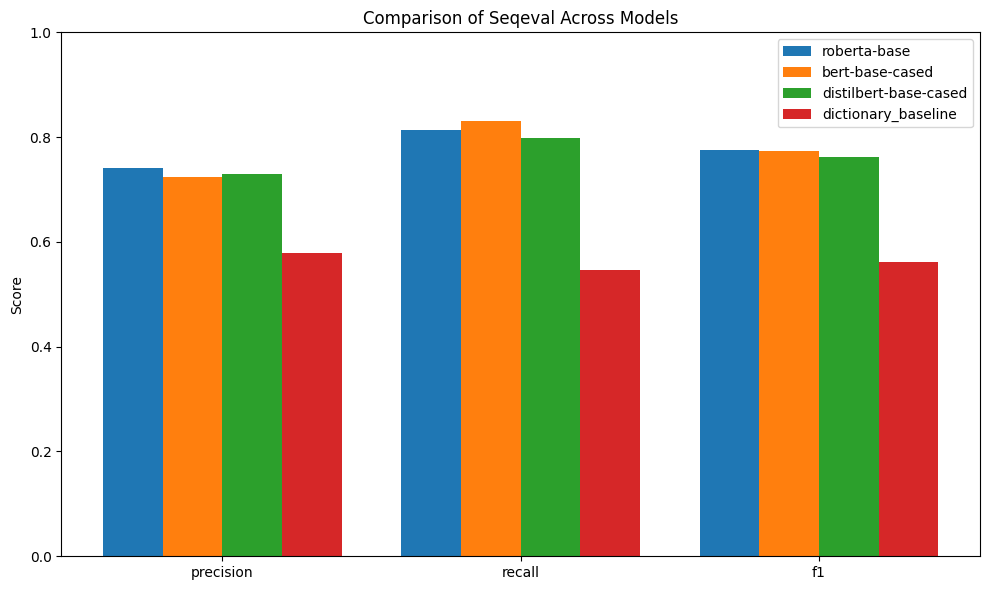

In [13]:
# get only the seqeval metrics
models = list(all_metrics.keys())
metrics = ['precision', 'recall', 'f1']
values = np.array([[all_metrics[m]['seqeval'][metric] for metric in metrics] for m in models])

# create the plot
x = np.arange(len(metrics))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models):
    ax.bar(x + i*width, values[i], width, label=model)
ax.set_xticks(x + width*(len(models)-1)/2)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Comparison of Seqeval Metrics Across Models')
ax.legend()
plt.tight_layout()
plt.show()

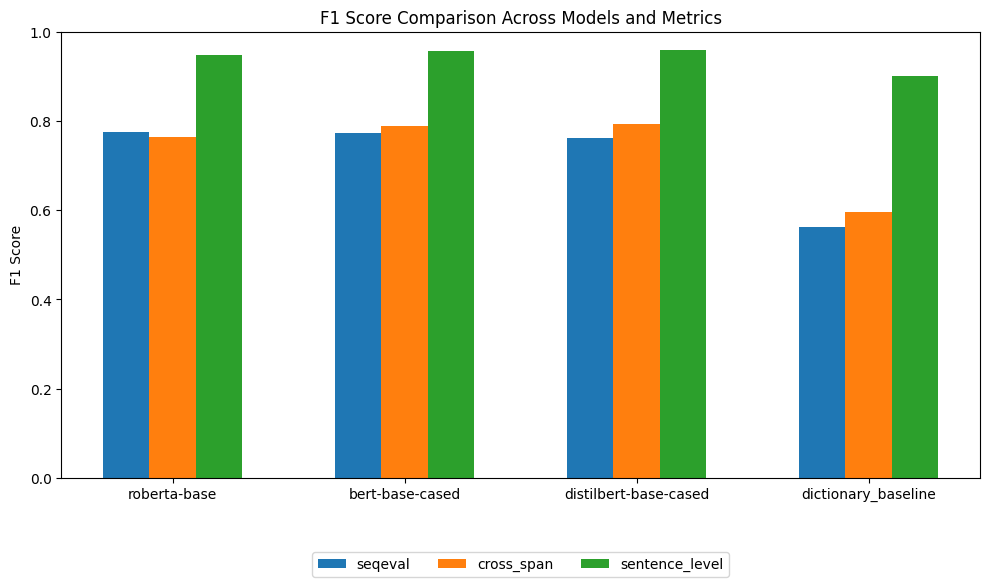

In [12]:
# define all metrics
sub_metrics = ['seqeval', 'cross_span', 'sentence_level']

# extract all f1 scores
f1_values = np.array([[all_metrics[m][sub]['f1'] for sub in sub_metrics] for m in models])

# create the plot
x = np.arange(len(models))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 6))
for i, sub in enumerate(sub_metrics):
    ax.bar(x + i*width, f1_values[:, i], width, label=sub)
ax.set_xticks(x + width)
ax.set_xticklabels(models)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.set_title('F1 Score Comparison Across Models and Metrics')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=len(sub_metrics))
plt.tight_layout()
plt.show()